<a href="https://colab.research.google.com/github/prudhvialeti7/bank-term-deposit-analysis.ipynb/blob/main/Client_subscribed_to_a_term_deposit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('/content/data.csv')
display(df.head())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Customer Demographics Analysis

In [ ]:
# Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

NameError: name 'plt' is not defined

In [ ]:
# Job distribution
plt.figure(figsize=(12, 7))
sns.countplot(y='job', data=df, order = df['job'].value_counts().index)
plt.title('Distribution of Job Categories')
plt.xlabel('Count')
plt.ylabel('Job Type')
plt.grid(axis='x', alpha=0.75)
plt.show()

## Balance & Deposit Trends

In [ ]:
# Average balance by deposit subscription
print(df.columns)
# balance_by_deposit = df.groupby('y')['Balance'].mean().reset_index()

# plt.figure(figsize=(8, 5))
# sns.barplot(x='y', y='Balance', data=balance_by_deposit)
# plt.title('Average Balance by Deposit Subscription')
# plt.xlabel('Deposit Subscription (Yes/No)')
# plt.ylabel('Average Balance')
# plt.grid(axis='y', alpha=0.75)
# plt.show()

KeyError: 'Column not found: Balance'

## Campaign Effectiveness

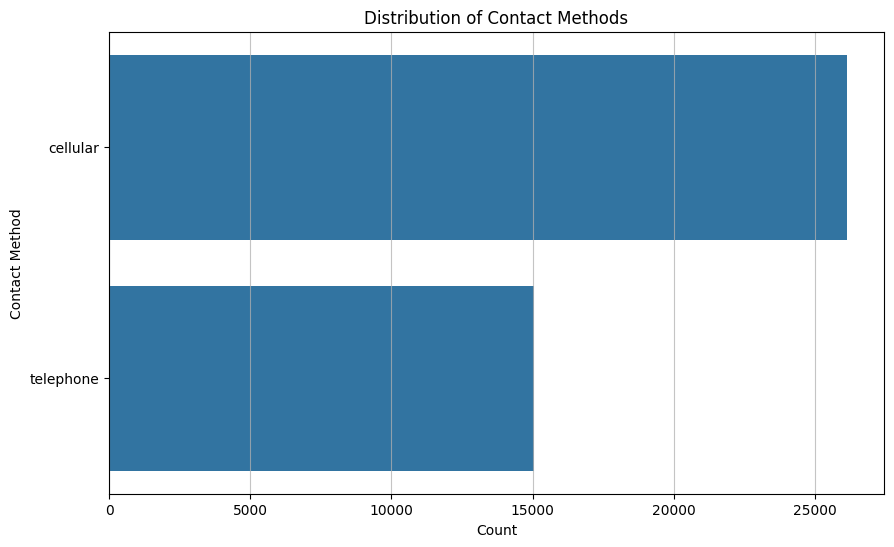

In [ ]:
# Contact method analysis
plt.figure(figsize=(10, 6))
sns.countplot(y='contact', data=df, order = df['contact'].value_counts().index)
plt.title('Distribution of Contact Methods')
plt.xlabel('Count')
plt.ylabel('Contact Method')
plt.grid(axis='x', alpha=0.75)
plt.show()

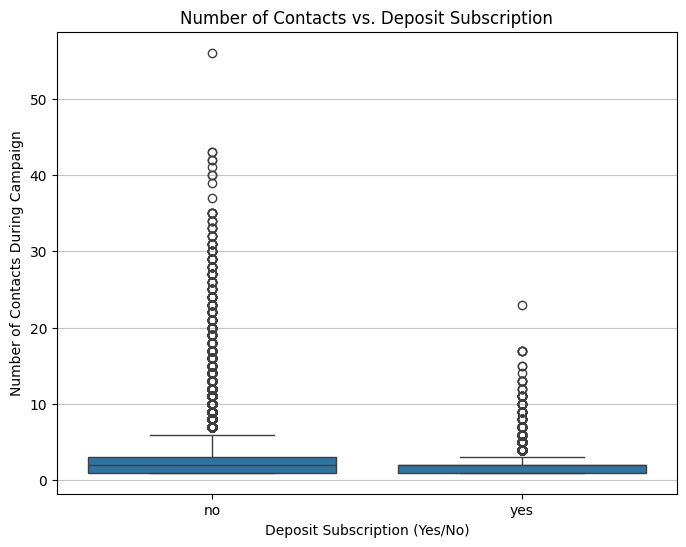

In [ ]:
# Number of contacts vs deposit subscription
plt.figure(figsize=(8, 6))
sns.boxplot(x='y', y='campaign', data=df)
plt.title('Number of Contacts vs. Deposit Subscription')
plt.xlabel('Deposit Subscription (Yes/No)')
plt.ylabel('Number of Contacts During Campaign')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Correlation Heatmap

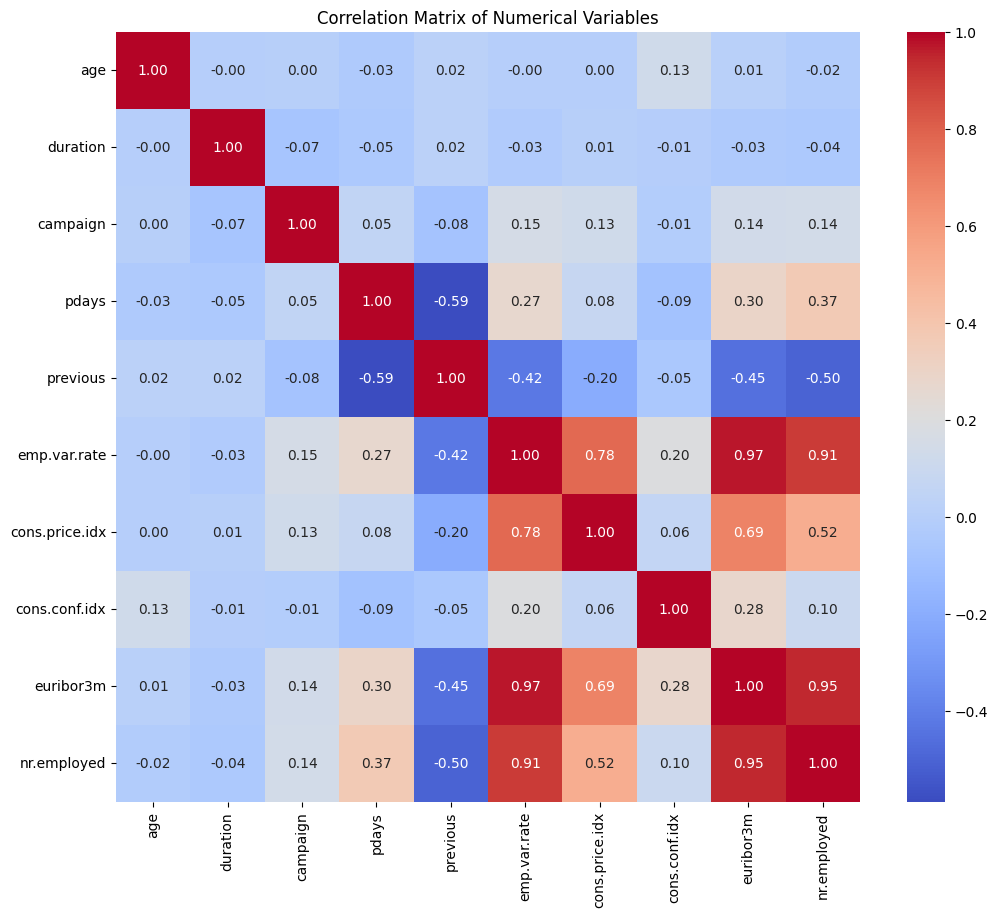

In [ ]:
# Correlation of numerical variables

# Select only numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

## Predictive Modeling (Logistic Regression)

In [ ]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)
display(df_encoded.head())

# Predictions

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,y_yes
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False


,feature,importance
43,month_may,0.920937
42,month_mar,0.474895
37,contact_telephone,0.395765
5,emp.var.rate,0.369869
6,cons.price.idx,0.367938
51,poutcome_nonexistent,0.283225
31,default_unknown,0.245050
40,month_jul,0.240873
4,previous,0.221405
41,month_jun,0.218805


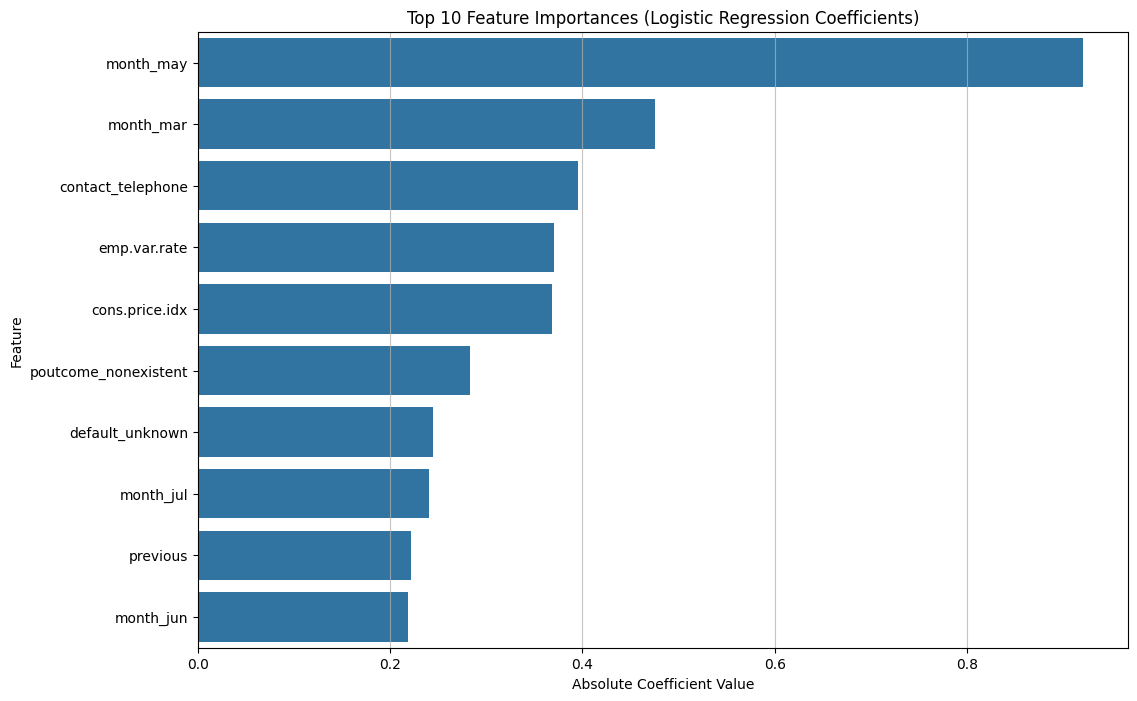

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np

# Define features (X) and target (y)
X = df_encoded.drop('y_yes', axis=1) # Assuming 'y_yes' is the target variable
y = df_encoded['y_yes']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Logistic Regression model
log_reg_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
log_reg_model.fit(X_train, y_train)

# Get feature importances (coefficients for Logistic Regression)
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': np.abs(log_reg_model.coef_[0])})
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

# Display top N important features
display(feature_importances.head(10))

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances.head(10))
plt.title('Top 10 Feature Importances (Logistic Regression Coefficients)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.75)
plt.show()

## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.